In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv("BUSCO/eukaryota_odb12/BUSCO.tsv", sep='\t')
df

,annotation_id,assembly_accession,species,lineage,busco_count,complete,single,duplicated,fragmented,missing,Well_annotated,Upstream,Downstream,Skipped,Out_of_frame,Spliced,Stop_codon,Selenocysteine_Gene_Count,Selenocysteine_GTF_Count,Selenocysteine_GTF_Count_Genes
0,015ef256fb19f410c935ef4db82e42c7,GCA_037194365.1,Opsariichthys_bidens,eukaryota_odb12,129,98.4,89.9,8.5,0.8,0.8,2,0,15,13,1,0,34,34,42,40
1,0ca33bb3c39173de0226ee2933b7ef55,GCA_947078765.1,Oryzias_latipes,eukaryota_odb12,129,97.7,97.7,0.0,2.3,0.0,0,9,9,57,1,0,13,36,37,36
2,017c803a2ff02d3912648265d4a031e1,GCA_901001165.1,Salmo_trutta,eukaryota_odb12,129,98.4,48.1,50.4,0.8,0.8,5,4,24,29,0,0,45,51,73,60
3,0d8e7b63a615e1e1a86c54193558e862,GCA_030014295.1,Loxodonta_africana,eukaryota_odb12,129,98.4,96.1,2.3,1.6,0.0,0,3,10,12,4,0,25,24,32,25
4,06ba1bb150b2e38bc77cf2c171aa5bb3,GCA_041937265.1,Sus_scrofa,eukaryota_odb12,129,96.9,94.6,2.3,3.1,0.0,10,2,0,14,1,0,14,23,32,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14015,95dbdb5d7178b3812c65cebf3bf6b971,GCA_911728515.1,Peribatodes_rhomboidaria,eukaryota_odb12,129,89.9,86.8,3.1,7.8,2.3,0,0,0,0,0,0,0,0,0,0
14016,55282f7d773c9ab9481833e227ef9180,GCA_001632525.1,Mus_musculus,eukaryota_odb12,129,97.7,96.9,0.8,2.3,0.0,43,10,5,1,3,0,7,24,33,33
14017,e5563c964f41c1d44012b5456e05cd60,GCA_042037855.1,Homo_sapiens,eukaryota_odb12,129,96.9,95.3,1.6,3.1,0.0,84,25,7,4,12,0,0,25,32,32
14018,845380a5a9804cbda0a80e1515e9eec6,GCA_001632615.1,Mus_musculus,eukaryota_odb12,129,98.4,97.7,0.8,1.6,0.0,42,10,6,2,3,0,7,24,32,32


Original rows: 14020
Rows after filtering: 5503
Rows dropped: 8517


/var/folders/kl/s2thrg3x7xv8yn26zr1j_pd80000gn/T/ipykernel_30946/1554459558.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{category}_pct'] = (df[category] / df['transcript_count'] * 100).round(2)


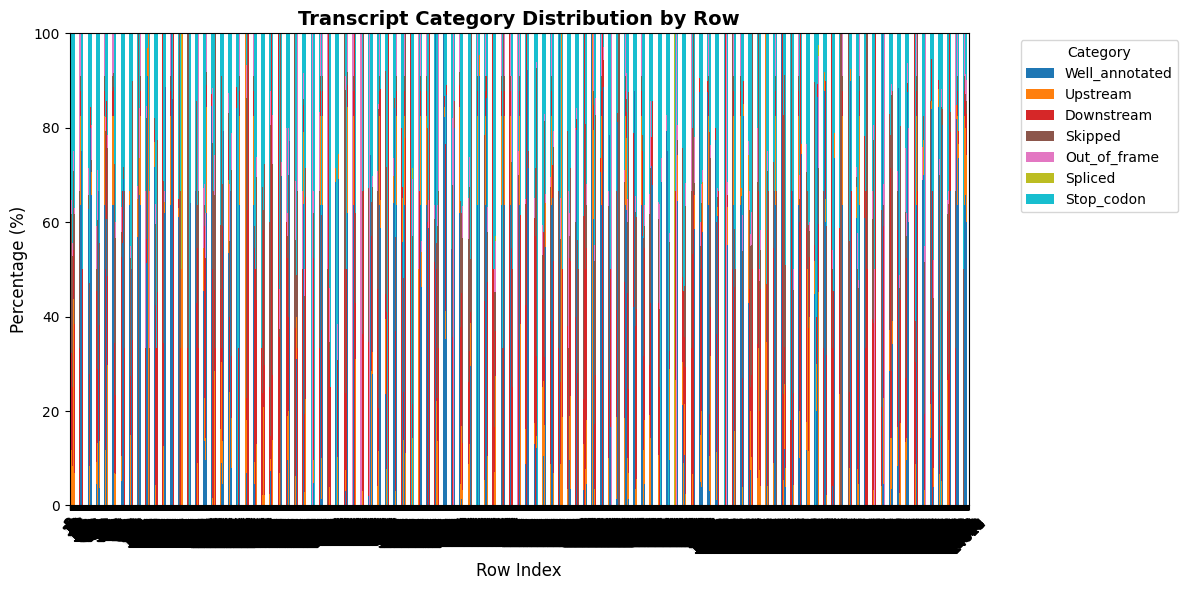

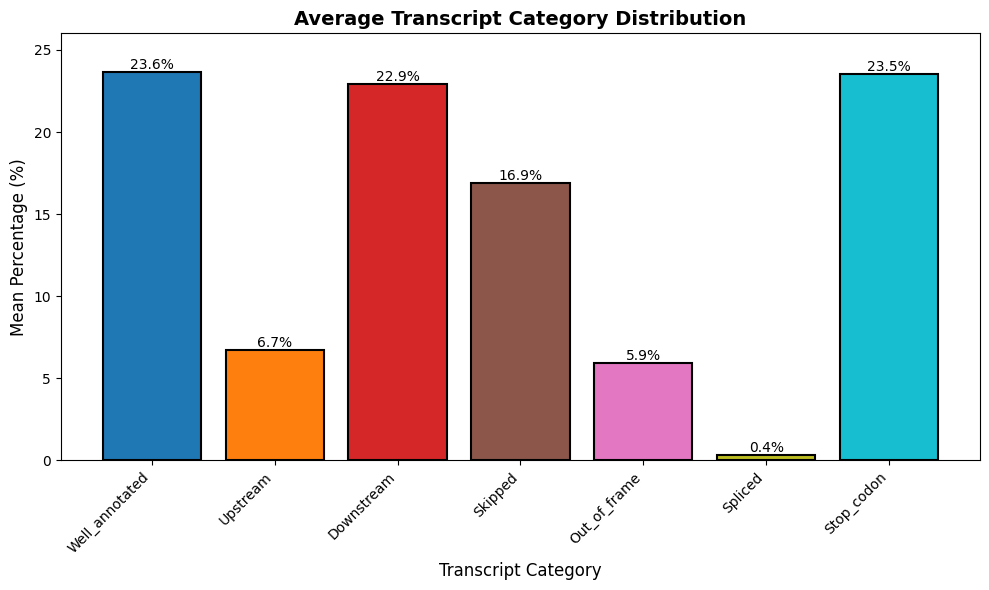

       Well_annotated_pct  Upstream_pct  Downstream_pct  Skipped_pct  \
0                    3.08          0.00           23.08        20.00   
1                    0.00         10.11           10.11        64.04   
2                    4.67          3.74           22.43        27.10   
3                    0.00          5.56           18.52        22.22   
4                   24.39          4.88            0.00        34.15   
...                   ...           ...             ...          ...   
14011                0.00         14.29           50.00        14.29   
14012                0.00          0.00            0.00       100.00   
14016               62.32         14.49            7.25         1.45   
14017               63.64         18.94            5.30         3.03   
14018               60.00         14.29            8.57         2.86   

       Out_of_frame_pct  Spliced_pct  Stop_codon_pct  
0                  1.54          0.0           52.31  
1                  1.12  

In [8]:
# Assess analysis of transcripts 
df['transcript_count'] = df["Well_annotated"] + df['Upstream'] + df['Downstream'] + df['Skipped'] + df['Out_of_frame'] + df['Spliced'] + df['Stop_codon']

# Store the original number of rows
original_rows = len(df)

# Drop rows where transcript_count is 0
df = df[df['transcript_count'] != 0]

# Calculate how many rows were dropped
dropped_rows = original_rows - len(df)

print(f"Original rows: {original_rows}")
print(f"Rows after filtering: {len(df)}")
print(f"Rows dropped: {dropped_rows}")

# Define transcript categories
categories = ["Well_annotated", "Upstream", "Downstream", "Skipped", "Out_of_frame", "Spliced", "Stop_codon"]

# Calculate percentages for each category
for category in categories:
    df[f'{category}_pct'] = (df[category] / df['transcript_count'] * 100).round(2)

# Option 1: Stacked Bar Plot (shows percentage composition for each row)
fig, ax = plt.subplots(figsize=(12, 6))

df_pct = df[[f'{cat}_pct' for cat in categories]]
df_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

ax.set_xlabel('Row Index', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Transcript Category Distribution by Row', fontsize=14, fontweight='bold')
ax.legend(title='Category', labels=categories, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim([0, 100])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Option 2: Mean percentages across all rows (single bar plot)
fig, ax = plt.subplots(figsize=(10, 6))

mean_pcts = [df[f'{cat}_pct'].mean() for cat in categories]
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
bars = ax.bar(categories, mean_pcts, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Transcript Category', fontsize=12)
ax.set_ylabel('Mean Percentage (%)', fontsize=12)
ax.set_title('Average Transcript Category Distribution', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(mean_pcts) * 1.1])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display percentage data
print(df[[f'{cat}_pct' for cat in categories]])

